## Импорты и окружение

In [1]:
import sys
import random
import logging
from pathlib import Path

import yaml
import numpy as np
import torch

PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils import get_device
from src.train import (
    build_dataloaders,
    build_model_bundle,
    log_ctc_capacity_warning,
    train_with_checkpoints,
    load_weights_for_inference,
    visualize_val_predictions,
    show_hard_val_examples,
    run_leaderboard_log,
)

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger('experiments')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

CONFIG_PATH = PROJECT_ROOT / 'configs' / 'config.yaml'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'checkpoints'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_PATH = OUTPUT_DIR / 'checkpoint.pth'
BEST_PATH = OUTPUT_DIR / 'best_model.pth'

DEVICE = get_device()

print('PROJECT_ROOT =', PROJECT_ROOT)
print('CONFIG_PATH =', CONFIG_PATH)
print('CHECKPOINT_PATH =', CHECKPOINT_PATH)
print('BEST_PATH =', BEST_PATH)
print('DEVICE =', DEVICE)


INFO:root:Device: MPS (Apple Metal Performance Shaders)


PROJECT_ROOT = /Users/user/PycharmProjects/Learning/MLC/projects/crnn-text-recognition
CONFIG_PATH = /Users/user/PycharmProjects/Learning/MLC/projects/crnn-text-recognition/configs/config.yaml
CHECKPOINT_PATH = /Users/user/PycharmProjects/Learning/MLC/projects/crnn-text-recognition/outputs/checkpoints/checkpoint.pth
BEST_PATH = /Users/user/PycharmProjects/Learning/MLC/projects/crnn-text-recognition/outputs/checkpoints/best_model.pth
DEVICE = mps


## Конфиг и пути к данным

Читается `configs/config.yaml`, пути к изображениям и CSV делаются абсолютными относительно `PROJECT_ROOT`.

Число эпох и `batch_size` задаются в **YAML**; для разового короткого обучения см. закомментированную строку **`config['epochs']`** в **ячейке с `train_with_checkpoints`**.

Флаг **`TRAINING`** задаётся там же, рядом с запуском эпох.


In [2]:
with open(CONFIG_PATH, 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

images_dir = Path(config['images_dir'])
labels_path = Path(config['labels_path'])
if not images_dir.is_absolute():
    images_dir = PROJECT_ROOT / images_dir
if not labels_path.is_absolute():
    labels_path = PROJECT_ROOT / labels_path

assert images_dir.is_dir(), f'Images directory not found: {images_dir}'
assert labels_path.is_file(), f'Labels file not found: {labels_path}'

print('images_dir =', images_dir)
print('labels_path =', labels_path)


images_dir = /Users/user/PycharmProjects/Learning/MLC/projects/crnn-text-recognition/data/raw/imgs1_w/imgs1
labels_path = /Users/user/PycharmProjects/Learning/MLC/projects/crnn-text-recognition/data/raw/imgs1_w/imgs1_text_recog.csv


## Данные и DataLoader’ы

Один датасет, разбиение **train / val** (доля и `split_seed` зашиты в `build_dataloaders` в `src/train.py`), загрузчики с collate для CTC.


In [3]:
dataset, train_dataset, val_dataset, train_loader, val_loader = build_dataloaders(
    str(images_dir),
    str(labels_path),
    config,
    split_seed=SEED,
)

print('Dataset size:', len(dataset))
print('Train size:', len(train_dataset))
print('Val size:', len(val_dataset))


INFO:src.data:Dataset loaded with 245995 samples (NaN filtered)


Dataset size: 245995
Train size: 196796
Val size: 49199


## Модель и проверка CTC

`build_model_bundle` — CRNN, Adam, CTC loss. `log_ctc_capacity_warning` — сколько подписей длиннее числа временных шагов T после CNN; если много, в конфиге обычно увеличивают `img_width`.


In [4]:
model, optimizer, criterion = build_model_bundle(config, DEVICE)
log_ctc_capacity_warning(model, dataset, config, DEVICE)


INFO:src.training_setup:Model time steps (T): 16
INFO:src.training_setup:Samples with label length > T: 384/245995


## Обучение (`train_with_checkpoints`)

**Терминал** (`python scripts/train.py`): каждый раз **новые веса**, `checkpoint.pth` не подгружается как старт; `best_model.pth` обновляется только если val **лучше** уже записанного в файле `best_val_loss`.

**Ноутбук (эта ячейка):** по умолчанию **`resume=True`** — если есть `checkpoint.pth`, подхватываются веса и оптимизатор, счётчик эпох продолжается. Если эпох в YAML уже «хватило» по чекпоинту, новых шагов не будет — увеличьте `epochs`, уберите чекпоинт или передайте **`resume=False`** (не читать `checkpoint.pth`; старт с текущих весов в `model`).

В **следующей кодовой ячейке** сразу перед вызовом: при необходимости **`config['epochs']`**, флаг **`TRAINING`**, **`use_tqdm=True`**, опционально **`resume=False`** (в комментарии).

В `outputs/checkpoints/` для обучения используются **два файла** с разными ролями:

| Файл | Что внутри | Когда появляется / обновляется | Зачем он вам |
|------|------------|-------------------------------|---------------|
| **`checkpoint.pth`** | Снимок **после последней завершённой эпохи**: веса модели, состояние оптимизатора, номер эпохи, лучший val на этот момент | Обновляется **каждую эпоху** во время обучения (ноутбук или терминал) | Чтобы **продолжить обучение** с того же места (`resume=True` в ноутбуке читает именно его) |
| **`best_model.pth`** | Веса той эпохи, у которой был **самый низкий val loss** за текущий «прогон» (и число этого лучшего val в словаре) | Перезаписывается **только когда** val стал новым рекордом | Обычно **его** подставляют в инференс как «лучшую модель», а не последнюю эпоху |


In [5]:
# Для короткого прогона обучения раскомментируйте (только на время запуска этой ячейки):
# config['epochs'] = 1

# TRAINING = True  # True: гонять эпохи;
TRAINING = False  # False: не гонять эпохи; тогда перед визуализацией запустите ячейку load_weights ниже

train_with_checkpoints(
    model,
    optimizer,
    criterion,
    train_loader,
    val_loader,
    config,
    DEVICE,
    CHECKPOINT_PATH,
    BEST_PATH,
    TRAINING,
    use_tqdm=True,
    # resume=False,  # раскомментировать: не грузить checkpoint.pth (после правок src — Restart kernel)
)


INFO:src.training_loop:TRAINING=False -> training skipped; load weights before eval.


## Подгрузка весов

Нужна, если обучение **не** запускали (`TRAINING = False` в ячейке выше) или хотите заново подтянуть `best_model.pth` / `checkpoint.pth` перед визуализацией.


In [6]:
load_weights_for_inference(model, BEST_PATH, CHECKPOINT_PATH, DEVICE)


INFO:src.training_loop:Checkpoint loaded: /Users/user/PycharmProjects/Learning/MLC/projects/crnn-text-recognition/outputs/checkpoints/best_model.pth


## Визуализация предсказаний на val

Переключатели **`USE_FIXED_SAMPLES`** и **`FIXED_SAMPLES_SEED`** заданы в **той же кодовой ячейке**, что и вызов (`True` — те же индексы при том же seed; `False` — случайная подвыборка).


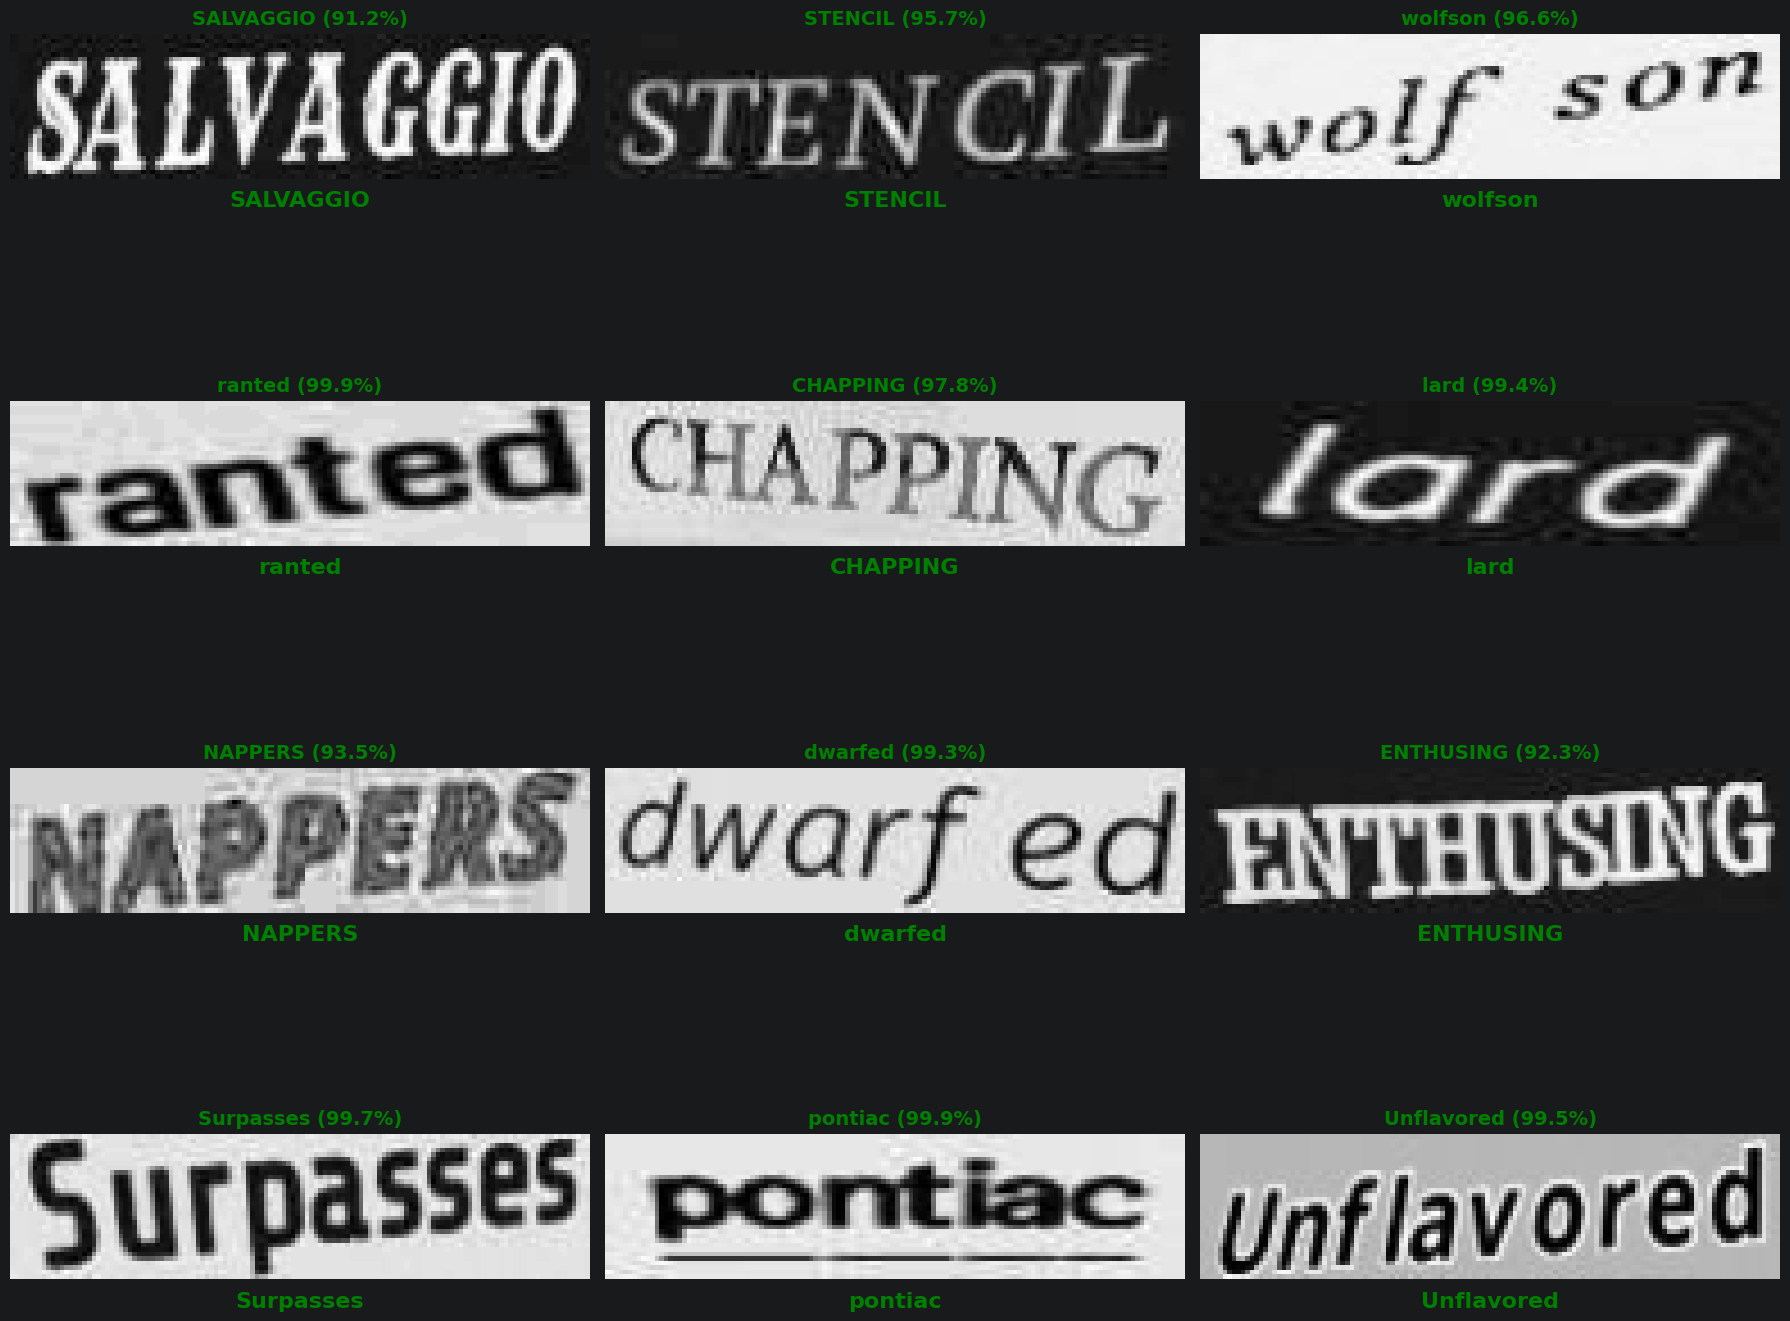

INFO:src.evaluation:Shown samples: 12
INFO:src.evaluation:Correct words: 12/12
INFO:src.evaluation:Accuracy: 1.000 | CER: 0.000 | WER: 0.000
INFO:src.evaluation:Average confidence: 97.1%


In [7]:
USE_FIXED_SAMPLES = False # True: те же индексы при fixed=True; False: случайная подвыборка
# USE_FIXED_SAMPLES = False # для разнообразия, не фиксировать выборку

FIXED_SAMPLES_SEED = 42

visualize_val_predictions(
    model,
    val_dataset,
    config,
    DEVICE,
    sample_count=12,
    fixed=USE_FIXED_SAMPLES,
    seed=FIXED_SAMPLES_SEED,
)


## Сложные примеры (ошибки)

Параметры **`ERROR_ANALYSIS_SAMPLES`**, **`ERROR_ANALYSIS_TOP_K`** и фиксация выборки задаются в **той же кодовой ячейке**, что и `show_hard_val_examples`.


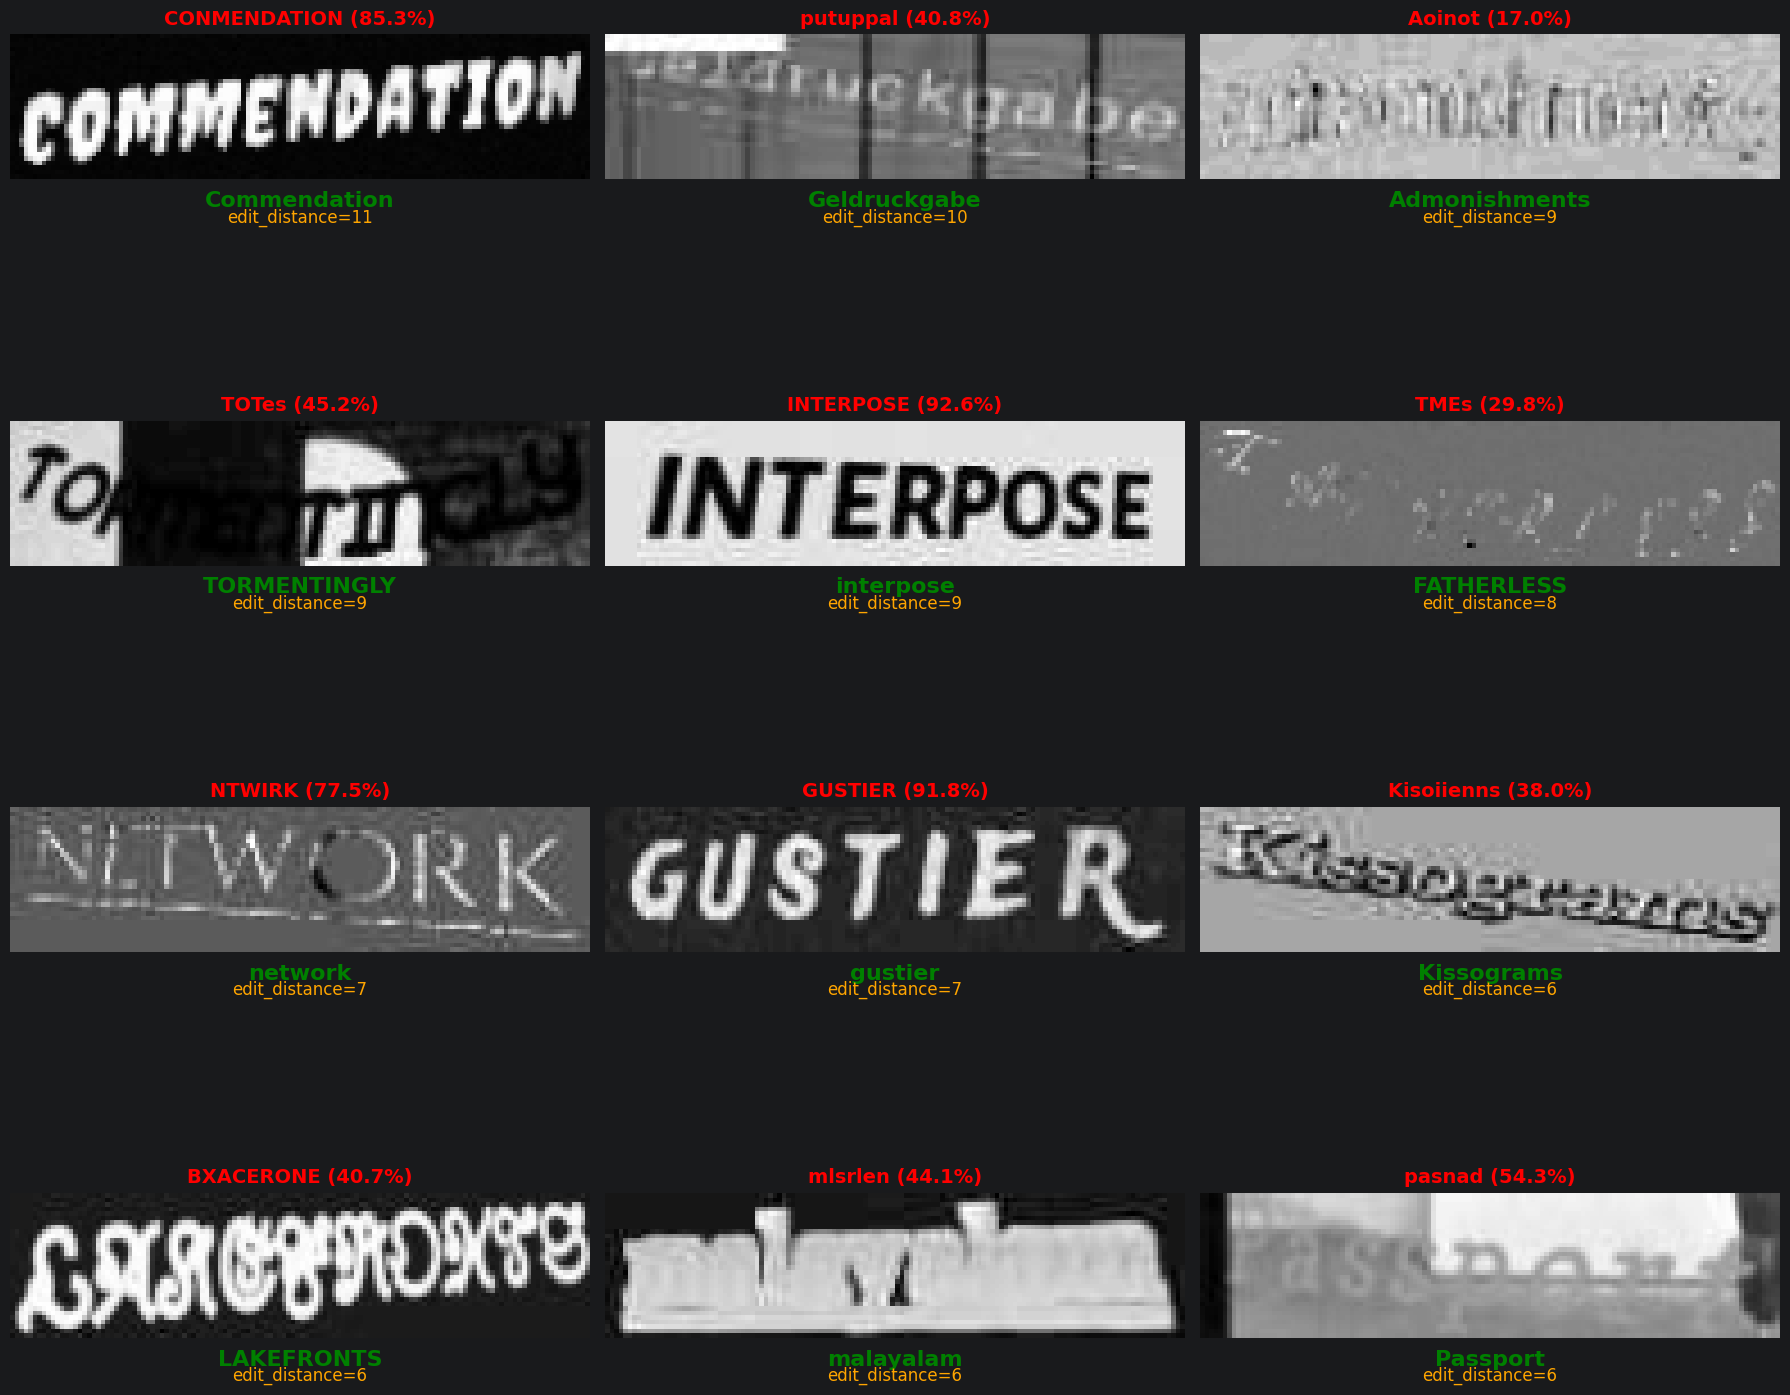

INFO:src.evaluation:Analyzed samples: 200 | mistakes: 72/200


In [8]:
USE_FIXED_SAMPLES = True  # как в визуализации: те же индексы при fixed=True
FIXED_SAMPLES_SEED = 42

ERROR_ANALYSIS_SAMPLES = 200
ERROR_ANALYSIS_TOP_K = 12

show_hard_val_examples(
    model,
    val_dataset,
    config,
    DEVICE,
    sample_count=ERROR_ANALYSIS_SAMPLES,
    top_k=ERROR_ANALYSIS_TOP_K,
    fixed=USE_FIXED_SAMPLES,
    seed=FIXED_SAMPLES_SEED,
)


## Лог эксперимента (leaderboard)

**В кодовой ячейке ниже** рядом с вызовом: **`LEADERBOARD_EVAL_SAMPLES`**, **`USE_FIXED_SAMPLES`**, **`FIXED_SAMPLES_SEED`**. Переменная **`TRAINING`** — та же, что в ячейке обучения (выполните её раньше, чтобы значение было в сессии); в CSV от неё только режим `train` / `inference_only`, на метрики не влияет.


In [9]:
USE_FIXED_SAMPLES = True
FIXED_SAMPLES_SEED = 42

LEADERBOARD_EVAL_SAMPLES = 500

run_leaderboard_log(
    model,
    val_dataset,
    config,
    DEVICE,
    PROJECT_ROOT,
    BEST_PATH,
    CHECKPOINT_PATH,
    TRAINING,
    sample_count=LEADERBOARD_EVAL_SAMPLES,
    fixed=USE_FIXED_SAMPLES,
    seed=FIXED_SAMPLES_SEED,
    note='leaderboard',
)


INFO:src.evaluation:Leaderboard subset | acc=64.80% cer=13.78% wer=35.20% conf=88.10% -> /Users/user/PycharmProjects/Learning/MLC/projects/crnn-text-recognition/outputs/experiment_log.csv
INFO:src.evaluation:Total logged runs: 9


,timestamp,mode,sample_count,accuracy_%,cer_%,wer_%,avg_conf_%,batch_size,lr,weights,note
0,2026-04-21 22:56:07,inference_only,500,64.8,13.78,35.2,88.10,32,0.001,best_model.pth,leaderboard
1,2026-04-22 10:03:45,inference_only,500,64.8,13.78,35.2,88.10,32,0.001,best_model.pth,leaderboard
2,2026-04-22 10:11:00,inference_only,500,64.8,13.78,35.2,88.10,32,0.001,best_model.pth,leaderboard
3,2026-04-22 11:04:19,inference_only,500,64.8,13.78,35.2,88.10,32,0.001,best_model.pth,leaderboard
4,2026-04-22 11:44:58,inference_only,500,64.8,13.78,35.2,88.10,32,0.001,best_model.pth,leaderboard
5,2026-04-22 13:36:56,inference_only,500,64.8,13.78,35.2,88.10,32,0.001,best_model.pth,leaderboard
6,2026-04-22 17:41:39,inference_only,500,64.8,13.78,35.2,88.10,32,0.001,best_model.pth,leaderboard
7,2026-04-21 21:30:26,inference_only,500,57.8,16.33,42.2,86.24,32,0.001,best_model.pth,leaderboard
8,2026-04-21 19:59:31,inference_only,500,57.2,15.04,42.8,86.95,32,0.001,best_model.pth,step5 leaderboard
